# PH04 — Huấn luyện ResNet18 trên HAM10000

Notebook này được chuyển từ `train_resnet.py` sang `.ipynb` để chạy local trên VS Code/Jupyter.

Mục tiêu:
- Dùng **ResNet18** để giảm nguy cơ overfitting khi source pretrain có khoảng 10k ảnh và fine-tune sau đó chỉ khoảng 1k ảnh.
- Lưu **best checkpoint** theo `val_acc`.
- Ghi **CSV log** gồm `epoch, train_loss, val_loss, val_acc, lr`.
- Vẽ biểu đồ bằng `matplotlib` để đưa vào báo cáo.

## 1. Import thư viện

In [ ]:
import csv
import time
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models

import pandas as pd
import matplotlib.pyplot as plt
import math, random
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


## 2. Thiết lập đường dẫn project

In [ ]:
# Notebook dự kiến nằm trong thư mục notebooks/
PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / 'src'
import sys
sys.path.insert(0, str(SRC_DIR))

from dataset import SkinDataset, NUM_CLASSES
from transforms import get_resnet_transforms

SPLIT_DIR = PROJECT_ROOT / 'data' / 'splits'
CKPT_DIR  = PROJECT_ROOT / 'checkpoints'
LOG_DIR   = PROJECT_ROOT / 'logs'
RES_DIR   = PROJECT_ROOT / 'results' / 'ph04_resnet_outputs'

CKPT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Project root : {PROJECT_ROOT}')
print(f'Device       : {DEVICE}')
print(f'Checkpoint   : {CKPT_DIR}')
print(f'Logs         : {LOG_DIR}')
print(f'Results      : {RES_DIR}')
print(f"split dir     : {SPLIT_DIR}")
if DEVICE.type == 'cuda':
    print(f'GPU          : {torch.cuda.get_device_name(0)}')

Project root : c:\Users\ADMIN\python\Phan_loai_ton_thuong_da_bang_ResNet_va_ViT
Device       : cuda
Checkpoint   : c:\Users\ADMIN\python\Phan_loai_ton_thuong_da_bang_ResNet_va_ViT\checkpoints
Logs         : c:\Users\ADMIN\python\Phan_loai_ton_thuong_da_bang_ResNet_va_ViT\logs
Results      : c:\Users\ADMIN\python\Phan_loai_ton_thuong_da_bang_ResNet_va_ViT\results\ph04_resnet_outputs
split dir     : c:\Users\ADMIN\python\Phan_loai_ton_thuong_da_bang_ResNet_va_ViT\data\splits
GPU          : NVIDIA GeForce RTX 4050 Laptop GPU


## 3. Cấu hình train

In [ ]:
BATCH_SIZE   = 64
NUM_EPOCHS   = 20
LR           = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS  = 0  # Windows an toàn hơn

print(f'BATCH_SIZE   = {BATCH_SIZE}')
print(f'NUM_EPOCHS   = {NUM_EPOCHS}')
print(f'LR           = {LR}')
print(f'WEIGHT_DECAY = {WEIGHT_DECAY}')
print(f'NUM_WORKERS  = {NUM_WORKERS}')

BATCH_SIZE   = 64
NUM_EPOCHS   = 20
LR           = 0.0001
WEIGHT_DECAY = 0.0001
NUM_WORKERS  = 0


## 4. Class weights cho dữ liệu mất cân bằng

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

def compute_class_weights(dataset):
    labels = dataset.df['label'].tolist()
    classes = sorted(dataset.df['label'].unique())
    weights = compute_class_weight('balanced', classes=np.array(classes), y=labels)
    return torch.tensor(weights, dtype=torch.float32)

## 5. Tạo dataset và dataloader

In [ ]:
train_ds = SkinDataset(
    SPLIT_DIR / 'ham10000_train.csv',
    transform=get_resnet_transforms('train')
)

val_ds = SkinDataset(
    SPLIT_DIR / 'ham10000_val.csv',
    transform=get_resnet_transforms('val')
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print(f'Train : {len(train_ds):,}')
print(f'Val   : {len(val_ds):,}')

Train : 8,488
Val   : 1,527


## 5b. Tên lớp HAM10000 (mới)

In [ ]:
HAM_LABEL_MAP = {'nv': 0, 'mel': 1, 'bkl': 2, 'bcc': 3, 'akiec': 4, 'vasc': 5, 'df': 6}
HAM_LABELS = sorted(HAM_LABEL_MAP.keys(), key=lambda x: HAM_LABEL_MAP[x])
print('HAM_LABELS:', HAM_LABELS)

HAM_LABELS: ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']


## 5c. Hàm visualize dùng chung (mới)

In [ ]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

def denormalize(tensor):
    img = tensor.detach().cpu().numpy().transpose(1, 2, 0)
    return np.clip(img * IMAGENET_STD + IMAGENET_MEAN, 0, 1)

def show_image_grid(images, titles=None, cols=4, figsize=(14, 9), save_path=None):
    rows = math.ceil(len(images) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(rows, cols)
    for ax in axes.flat:
        ax.axis('off')
    for i, img in enumerate(images):
        axes.flat[i].imshow(img)
        if titles:
            axes.flat[i].set_title(titles[i], fontsize=8)
        axes.flat[i].axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()

def collect_predictions(model, loader, device):
    model.eval()
    all_imgs, all_true, all_pred, all_probs = [], [], [], []
    with torch.no_grad():
        for images, labels in loader:
            out   = model(images.to(device))
            probs = torch.softmax(out, dim=1)
            all_imgs.extend(images.cpu())
            all_true.extend(labels.numpy().tolist())
            all_pred.extend(out.argmax(dim=1).cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())
    return all_imgs, np.array(all_true), np.array(all_pred), np.array(all_probs)

## 5d. Kiểm tra augmentation đầu vào (mới)

Saved: c:\Users\ADMIN\python\Phan_loai_ton_thuong_da_bang_ResNet_va_ViT\results\ph04_resnet_outputs\label_sample_ham10000.png


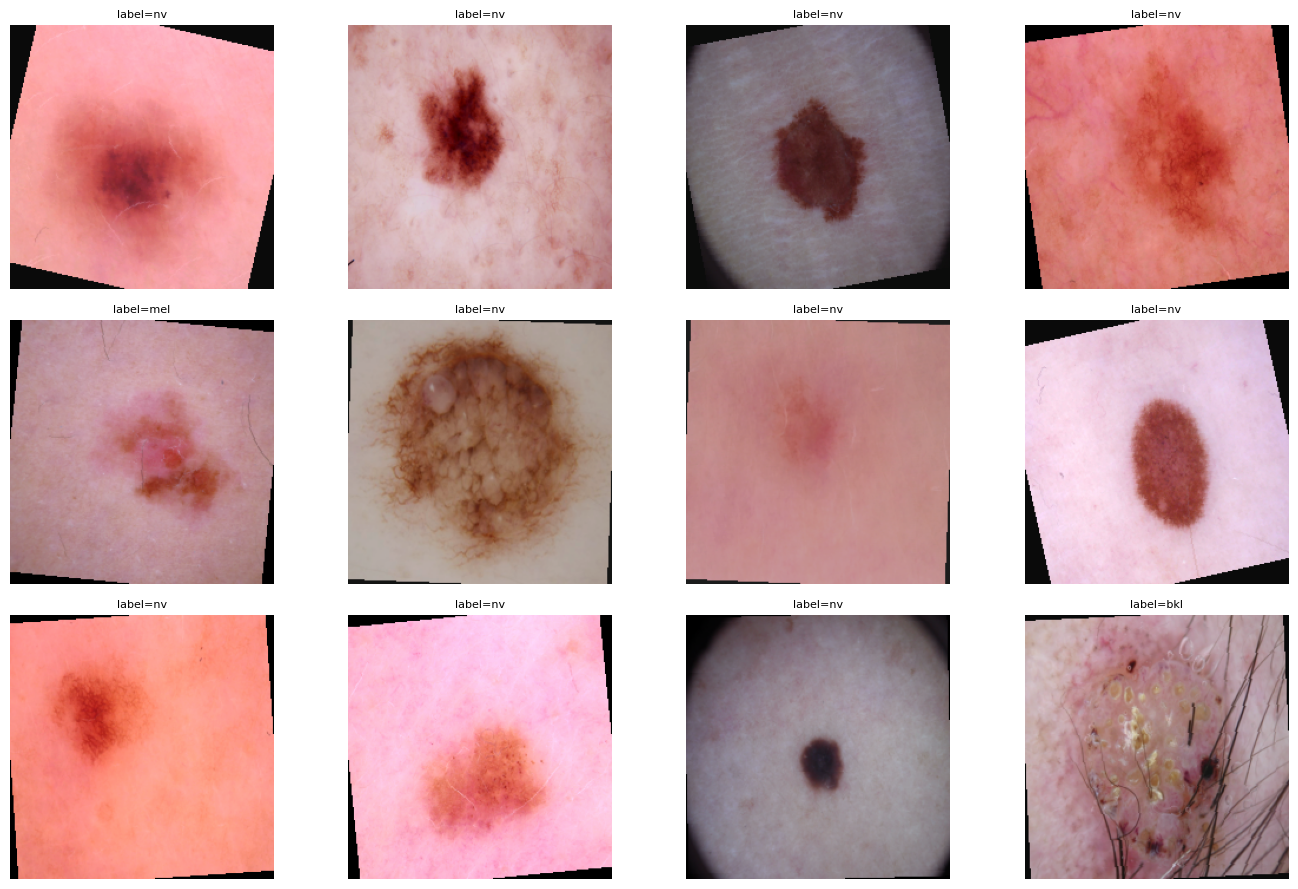

In [ ]:
batch_imgs, batch_lbls = next(iter(train_loader))

aug_imgs   = [denormalize(batch_imgs[i]) for i in range(12)]
aug_titles = [f'label={HAM_LABELS[batch_lbls[i].item()]}' for i in range(12)]

show_image_grid(
    aug_imgs,
    titles=aug_titles,
    cols=4,
    figsize=(14, 9),
    save_path=RES_DIR / 'label_sample_ham10000.png'
)

## 6. Xây dựng ResNet18

In [ ]:
def build_source_model_from_imagenet():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Freeze backbone — chỉ train head mới
    for param in model.parameters():
        param.requires_grad = False

    # Thay classification head: 512 → NUM_CLASSES (7 lớp HAM10000)
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, NUM_CLASSES),
    )
    return model


model = build_source_model_from_imagenet().to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=compute_class_weights(train_ds).to(DEVICE))
optimizer = torch.optim.Adam(model.fc.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

print(model.fc)


Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=7, bias=True)
)


## 7. Hàm train và validate

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)


def validate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)


## 8. Train ResNet18 và lưu best model

In [ ]:
log_path = LOG_DIR / 'resnet18_log.csv'

with open(log_path, 'w', newline='') as f:
    csv.writer(f).writerow(['epoch', 'train_loss', 'val_loss', 'val_acc', 'lr'])

best_val_acc = 0.0
unfreeze_done = False

for epoch in range(1, NUM_EPOCHS + 1):
    if epoch == 6 and not unfreeze_done:
        print('\n[Unfreeze] Mở backbone để fine-tune toàn bộ...')
        for p in model.parameters():
            p.requires_grad = True

        optimizer = torch.optim.Adam([
            {'params': model.fc.parameters(), 'lr': LR},
            {'params': [p for n, p in model.named_parameters() if 'fc' not in n], 'lr': LR * 0.1},
        ], weight_decay=WEIGHT_DECAY)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
        unfreeze_done = True
        # Thêm dòng này để reset patience counter về 0 sau unfreeze
        scheduler.num_bad_epochs = 0

    t0 = time.time()
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = validate(model, val_loader, criterion)
    scheduler.step(val_loss)

    print(
        f'Epoch [{epoch:02d}/{NUM_EPOCHS}] ' +
        f'train_loss={train_loss:.4f} ' +
        f'val_loss={val_loss:.4f} ' +
        f'val_acc={val_acc:.4f} ' +
        f'({time.time() - t0:.1f}s)'
    )

    with open(log_path, 'a', newline='') as f:
        csv.writer(f).writerow([
            epoch,
            f'{train_loss:.6f}',
            f'{val_loss:.6f}',
            f'{val_acc:.6f}',
            f'{optimizer.param_groups[0]["lr"]:.2e}'
        ])

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        # Lưu best checkpoint của model_source (HAM10000).
        # File này sẽ được load lại ở PH-05 để làm điểm khởi đầu
        # cho transfer learning (fine-tune) sang tập Derm7pt.
        torch.save(
            {
                'epoch': epoch,
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_loss': val_loss,
            },
            CKPT_DIR / 'resnet18_best.pth'
        )
        print(f'✅ Saved best val_acc = {val_acc:.4f}')

print(f'\nDone. Best val_acc = {best_val_acc:.4f}')

Epoch [01/20] train_loss=2.0704 val_loss=1.7685 val_acc=0.3523 (100.3s)
✅ Saved best val_acc = 0.3523
Epoch [02/20] train_loss=1.9401 val_loss=1.6466 val_acc=0.4407 (110.2s)
✅ Saved best val_acc = 0.4407
Epoch [03/20] train_loss=1.8196 val_loss=1.5198 val_acc=0.5056 (104.3s)
✅ Saved best val_acc = 0.5056
Epoch [04/20] train_loss=1.7363 val_loss=1.5641 val_acc=0.4682 (106.5s)
Epoch [05/20] train_loss=1.6781 val_loss=1.5211 val_acc=0.4872 (92.9s)

[Unfreeze] Mở backbone để fine-tune toàn bộ...
Epoch [06/20] train_loss=1.4294 val_loss=1.2558 val_acc=0.5619 (109.1s)
✅ Saved best val_acc = 0.5619
Epoch [07/20] train_loss=1.1378 val_loss=1.1652 val_acc=0.5828 (109.3s)
✅ Saved best val_acc = 0.5828
Epoch [08/20] train_loss=0.9749 val_loss=0.9900 val_acc=0.6379 (108.5s)
✅ Saved best val_acc = 0.6379
Epoch [09/20] train_loss=0.8582 val_loss=0.9814 val_acc=0.6333 (133.0s)
Epoch [10/20] train_loss=0.7991 val_loss=0.9231 val_acc=0.6516 (147.5s)
✅ Saved best val_acc = 0.6516
Epoch [11/20] train_los

## 9. Đọc CSV log

In [ ]:
df_log = pd.read_csv(log_path)
df_log

,epoch,train_loss,val_loss,val_acc,lr
0,1,2.070381,1.768462,0.352325,0.0001
1,2,1.940066,1.646568,0.440733,0.0001
2,3,1.819558,1.519849,0.505566,0.0001
3,4,1.736281,1.564131,0.468238,0.0001
4,5,1.678135,1.521147,0.487230,0.0001
5,6,1.429408,1.255806,0.561886,0.0001
6,7,1.137848,1.165208,0.582842,0.0001
7,8,0.974855,0.989996,0.637852,0.0001
8,9,0.858238,0.981431,0.633268,0.0001
9,10,0.799052,0.923133,0.651604,0.0001


## 10. Vẽ biểu đồ bằng matplotlib

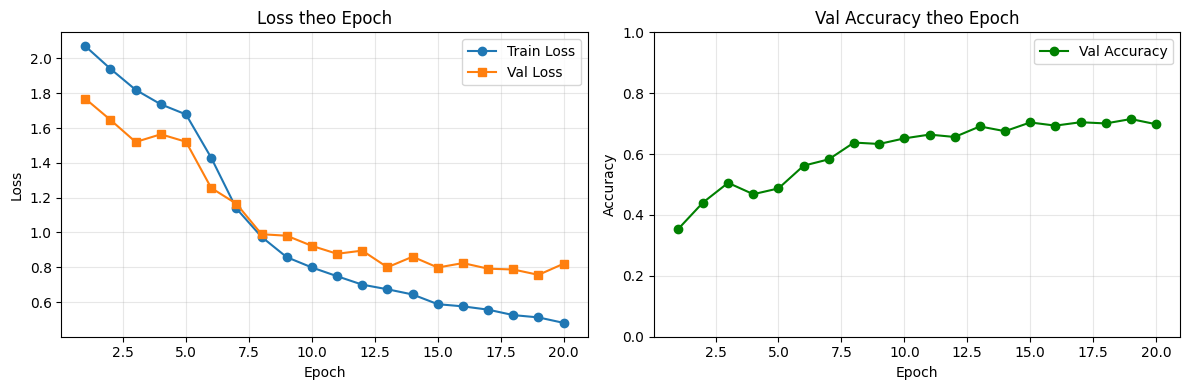

Đã lưu biểu đồ tại: c:\Users\ADMIN\python\Phan_loai_ton_thuong_da_bang_ResNet_va_ViT\results\ph04_resnet_outputs\loss_val_resnet18.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df_log['epoch'], df_log['train_loss'], marker='o', label='Train Loss')
axes[0].plot(df_log['epoch'], df_log['val_loss'], marker='s', label='Val Loss')
axes[0].set_title('Loss theo Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_log['epoch'], df_log['val_acc'], marker='o', color='green', label='Val Accuracy')
axes[1].set_title('Val Accuracy theo Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RES_DIR / 'loss_val_resnet18.png', dpi=150)
plt.show()

print(f'Đã lưu biểu đồ tại: {RES_DIR / "loss_val_resnet18.png"}')

## 11. Load best checkpoint để visualize (mới)

In [ ]:
ckpt = torch.load(CKPT_DIR / 'resnet18_best.pth', map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state'])
model = model.to(DEVICE)
model.eval()
print(f"Loaded best checkpoint — epoch={ckpt['epoch']}, val_acc={ckpt['val_acc']:.4f}")

Loaded best checkpoint — epoch=19, val_acc=0.7151


## 12. Sample predictions đúng / sai trên Validation set (mới)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_32188\3936732887.py:19: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_32188\3936732887.py:19: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_32188\3936732887.py:21: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=200, bbox_inches='tight')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_32188\3936732887.py:21: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=200, bbox_inches='tight')


Saved: c:\Users\ADMIN\python\Phan_loai_ton_thuong_da_bang_ResNet_va_ViT\results\ph04_resnet_outputs\resnet_ham10000_val_predictions.png


c:\Users\ADMIN\python\Phan_loai_ton_thuong_da_bang_ResNet_va_ViT\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ADMIN\python\Phan_loai_ton_thuong_da_bang_ResNet_va_ViT\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


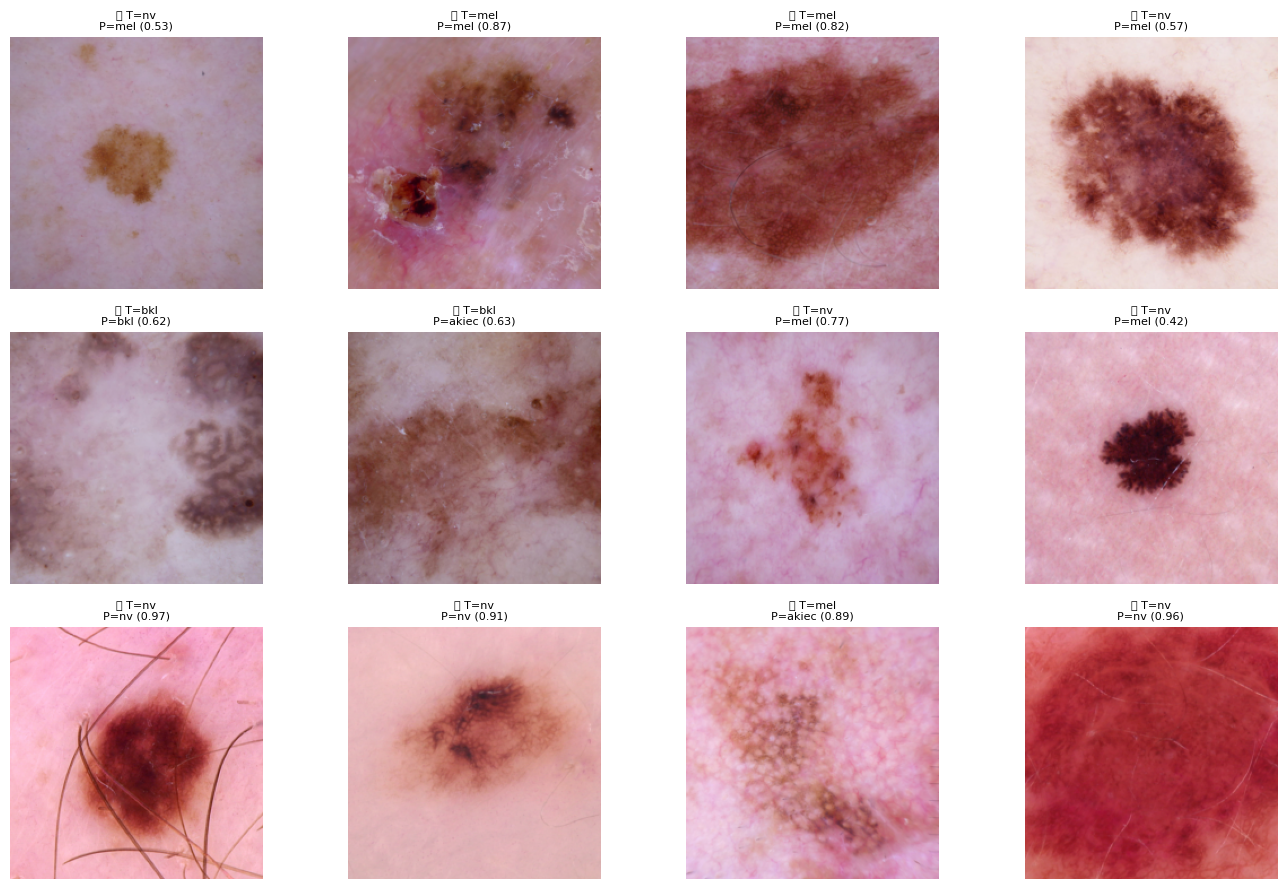

In [ ]:
all_imgs, y_true, y_pred, y_probs = collect_predictions(model, val_loader, DEVICE)

random.seed(42)
idxs = list(range(len(all_imgs)))
random.shuffle(idxs)
sample_idxs = idxs[:12]

vis_imgs, vis_titles = [], []
for i in sample_idxs:
    mark = '✅' if y_true[i] == y_pred[i] else '❌'
    vis_imgs.append(denormalize(all_imgs[i]))
    vis_titles.append(
        f"{mark} T={HAM_LABELS[y_true[i]]}\nP={HAM_LABELS[y_pred[i]]} ({y_probs[i][y_pred[i]]:.2f})"
    )

show_image_grid(
    vis_imgs,
    titles=vis_titles,
    cols=4,
    figsize=(14, 9),
    save_path=RES_DIR / 'resnet_ham10000_val_predictions.png'
)

## 13. Confusion Matrix trên Validation set (mới)

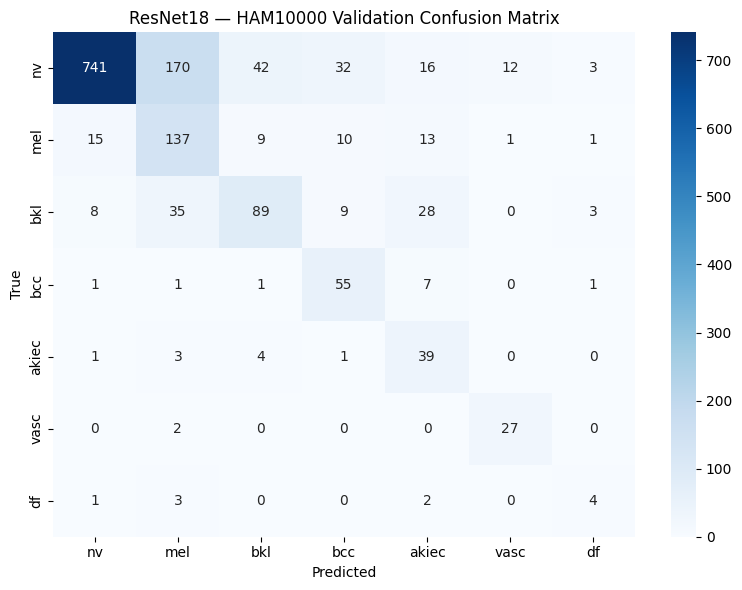

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=HAM_LABELS, yticklabels=HAM_LABELS)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('ResNet18 — HAM10000 Validation Confusion Matrix')
plt.tight_layout()
plt.show()

## 14. Classification Report (mới)

In [ ]:
report = classification_report(y_true, y_pred, target_names=HAM_LABELS, digits=4)
print(report)

with open(RES_DIR / 'resnet_ham10000_classification_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)
print('Saved classification report.')

              precision    recall  f1-score   support

          nv     0.9661    0.7293    0.8312      1016
         mel     0.3903    0.7366    0.5102       186
         bkl     0.6138    0.5174    0.5615       172
         bcc     0.5140    0.8333    0.6358        66
       akiec     0.3714    0.8125    0.5098        48
        vasc     0.6750    0.9310    0.7826        29
          df     0.3333    0.4000    0.3636        10

    accuracy                         0.7151      1527
   macro avg     0.5520    0.7086    0.5993      1527
weighted avg     0.8084    0.7151    0.7392      1527

Saved classification report.
